In [1]:
# Import thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Cấu hình giao diện biểu đồ (Style đẹp để lên Slide)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

# 1. Load dữ liệu
# Đảm bảo file csv nằm đúng thư mục data/processed/
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')

# 2. Convert Timestamp sang dạng datetime chuẩn
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 3. Kiểm tra nhanh dữ liệu
print(f"Total number of data rows: {len(df)}")
print(f"Total number of users: {df['Id'].nunique()}")
print(f"Time period: from {df['Timestamp'].min()} to {df['Timestamp'].max()}")

# 4. Tách dữ liệu của 1 User cụ thể để vẽ (Chọn User đầu tiên: 8792009665)
user_id = 8792009665
user_df = df[df['Id'] == user_id].copy()

# Set index là thời gian để vẽ Time Series
user_df.set_index('Timestamp', inplace=True)
user_df.sort_index(inplace=True)

print(f"\nCurrently analyzing the data for User ID: {user_id}")
user_df.head()

Total number of data rows: 148270
Total number of users: 14
Time period: from 2016-03-29 00:00:00 to 2016-04-12 11:03:00

Currently analyzing the data for User ID: 8792009665


,Id,Heart_Rate,Steps,Calories,Intensity
Timestamp,,,,,
2016-04-01 00:00:00,8792009665,81.000000,0.066667,1.466667,0.016667
2016-04-01 00:01:00,8792009665,82.714286,0.066667,1.466667,0.016667
2016-04-01 00:02:00,8792009665,80.833333,0.066667,1.466667,0.016667
2016-04-01 00:03:00,8792009665,80.000000,0.066667,1.466667,0.016667
2016-04-01 00:04:00,8792009665,82.333333,0.066667,1.466667,0.016667


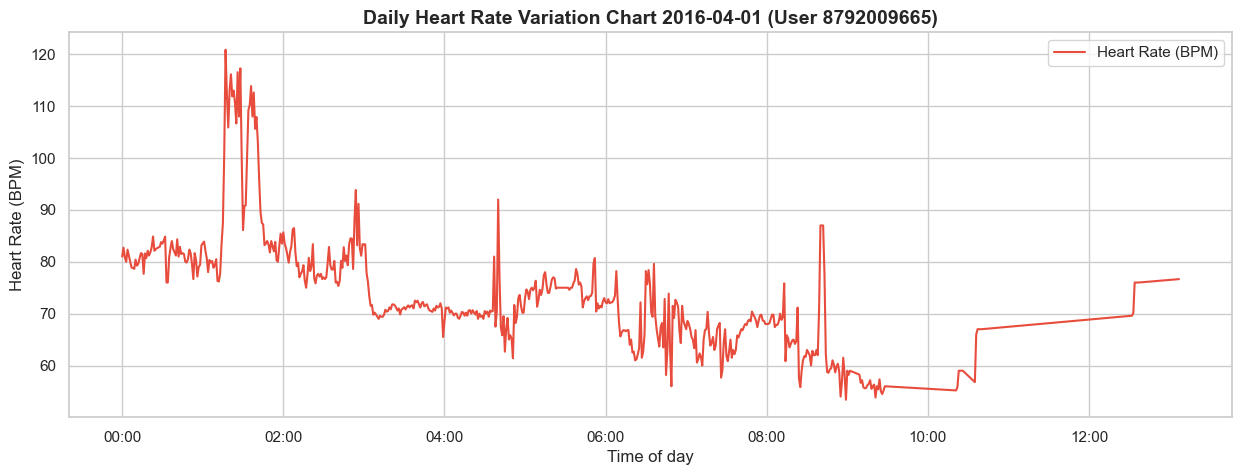

In [2]:
# Lọc dữ liệu ngày 01/04/2016
day_to_plot = '2016-04-01'
daily_data = user_df.loc[day_to_plot]

plt.figure(figsize=(15, 5))

# Vẽ đường nhịp tim
plt.plot(daily_data.index, daily_data['Heart_Rate'], 
         color='#e74c3c', linewidth=1.5, label='Heart Rate (BPM)')

# Trang trí
plt.title(f'Daily Heart Rate Variation Chart {day_to_plot} (User {user_id})', fontsize=14, fontweight='bold')
plt.ylabel('Heart Rate (BPM)')
plt.xlabel('Time of day')
plt.legend()

# Định dạng trục X hiển thị giờ:phút
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.show()

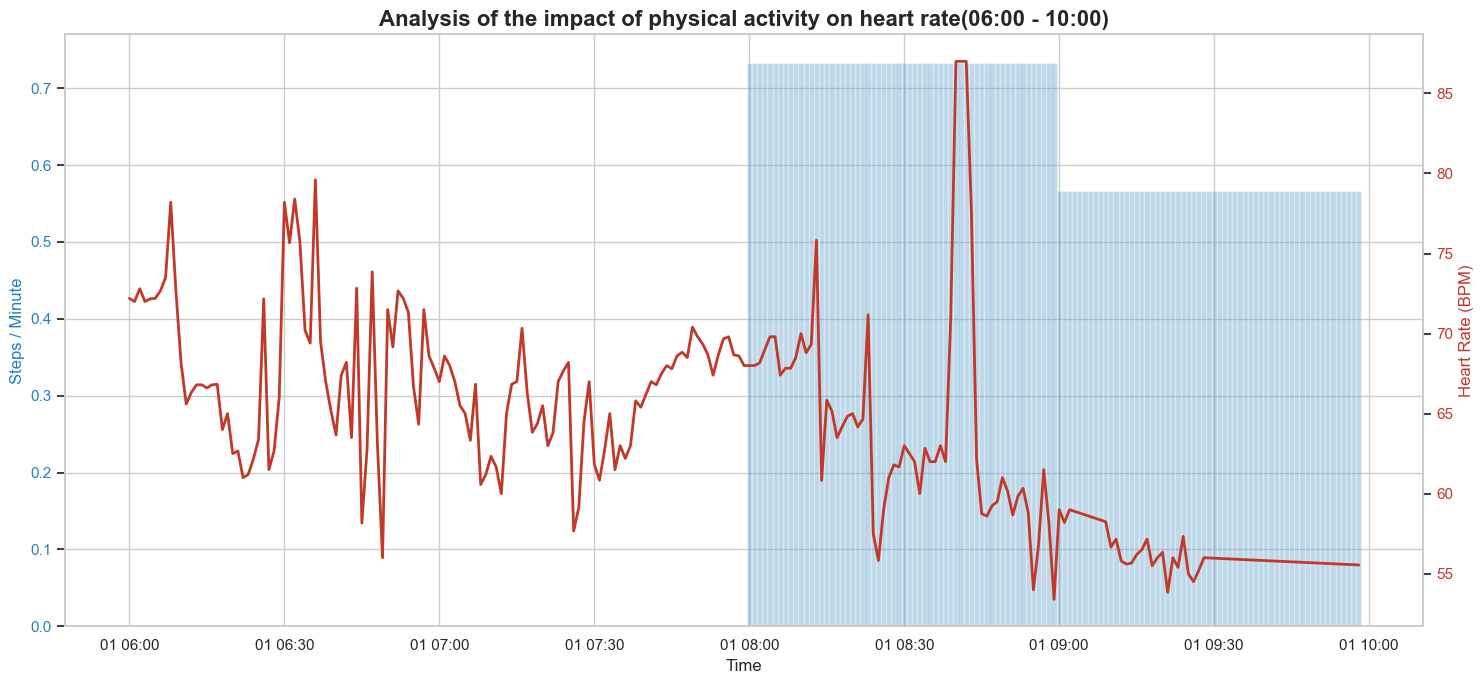

In [3]:
# Chọn khung giờ buổi sáng có hoạt động
start_time = '2016-04-01 06:00:00'
end_time = '2016-04-01 10:00:00'
zoom_df = user_df.loc[start_time:end_time]

fig, ax1 = plt.subplots(figsize=(15, 7))

# TRỤC TRÁI: Steps (Dạng cột)
color_steps = '#2980b9'
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Steps / Minute', color=color_steps, fontsize=12)
ax1.bar(zoom_df.index, zoom_df['Steps'], color=color_steps, alpha=0.3, width=0.0007, label='Steps')
ax1.tick_params(axis='y', labelcolor=color_steps)

# TRỤC PHẢI: Heart Rate (Dạng đường)
ax2 = ax1.twinx()
color_hr = '#c0392b'
ax2.set_ylabel('Heart Rate (BPM)', color=color_hr, fontsize=12)
ax2.plot(zoom_df.index, zoom_df['Heart_Rate'], color=color_hr, linewidth=2, linestyle='-', label='Heart Rate')
ax2.tick_params(axis='y', labelcolor=color_hr)

# Tiêu đề
plt.title('Analysis of the impact of physical activity on heart rate(06:00 - 10:00)', fontsize=16, fontweight='bold')
plt.grid(False) # Tắt lưới để đỡ rối

fig.tight_layout()
plt.show()

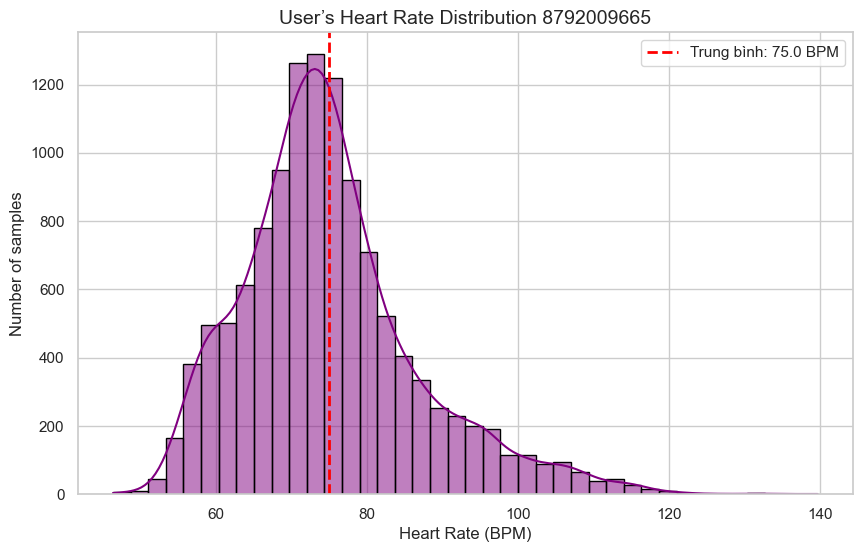

In [4]:
plt.figure(figsize=(10, 6))

# Vẽ Histogram
sns.histplot(user_df['Heart_Rate'], bins=40, kde=True, color='purple', edgecolor='black')

# Vẽ đường trung bình
mean_val = user_df['Heart_Rate'].mean()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Trung bình: {mean_val:.1f} BPM')

plt.title(f'User’s Heart Rate Distribution {user_id}', fontsize=14)
plt.xlabel('Heart Rate (BPM)')
plt.ylabel('Number of samples')
plt.legend()

plt.show()